In [12]:
import os
print(os.getcwd())


/home/ahasan/projects/hardware-aware-router/src/hardware_cost_model


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# ==== CHANGE THESE ====
carrot_id = "20251117-004302"
hw_id     = "20251117-094731"   # replace with your real id

BASE = "/home/ahasan/projects/hardware-aware-router/data/router_eval_runs"

carrot_gpu = f"{BASE}/{carrot_id}_gpu_monitor.csv"
hw_gpu     = f"{BASE}/{hw_id}_gpu_monitor.csv"

carrot_router = f"{BASE}/{carrot_id}_router_results.csv"
hw_router     = f"{BASE}/{hw_id}_router_results.csv"


In [29]:
df_cg = pd.read_csv(carrot_gpu)
df_hg = pd.read_csv(hw_gpu)

df_cr = pd.read_csv(carrot_router)
df_hr = pd.read_csv(hw_router)

df_cg.head(), df_hg.head()


(      timestamp  gpu_id  running  waiting  kv_cache_usage
 0  1.763358e+09       0      0.0      0.0             0.0
 1  1.763358e+09       1      0.0      0.0             0.0
 2  1.763358e+09       0      0.0      0.0             0.0
 3  1.763358e+09       1      0.0      0.0             0.0
 4  1.763358e+09       0      0.0      0.0             0.0,
       timestamp  gpu_id  running  waiting  kv_cache_usage
 0  1.763391e+09       0      0.0      0.0             0.0
 1  1.763391e+09       1      0.0      0.0             0.0
 2  1.763391e+09       0      0.0      0.0             0.0
 3  1.763391e+09       1      0.0      0.0             0.0
 4  1.763391e+09       0      0.0      0.0             0.0)

In [30]:
df_cg["timestamp"] = df_cg["timestamp"].astype(float)
df_hg["timestamp"] = df_hg["timestamp"].astype(float)

df_cg["t_rel"] = df_cg["timestamp"] - df_cg["timestamp"].min()
df_hg["t_rel"] = df_hg["timestamp"] - df_hg["timestamp"].min()


In [31]:
T = min(df_cg["t_rel"].max(), df_hg["t_rel"].max())

cg = df_cg[df_cg["t_rel"] <= T].copy()
hg = df_hg[df_hg["t_rel"] <= T].copy()


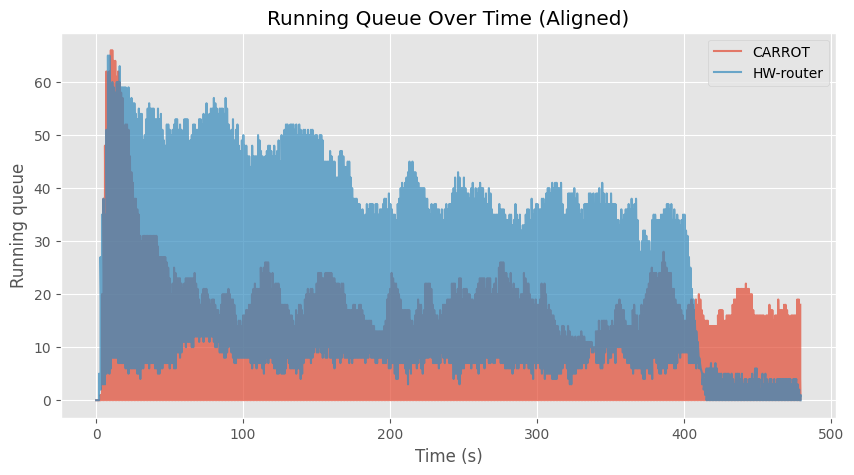

In [32]:
plt.figure(figsize=(10,5))
plt.plot(cg["t_rel"], cg["running"], alpha=0.7, label="CARROT")
plt.plot(hg["t_rel"], hg["running"], alpha=0.7, label="HW-router")
plt.title("Running Queue Over Time (Aligned)")
plt.xlabel("Time (s)")
plt.ylabel("Running queue")
plt.legend()
plt.show()


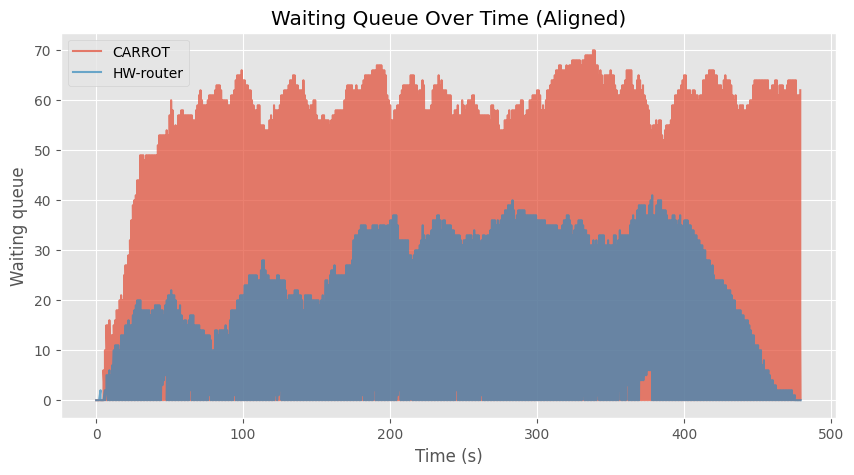

In [33]:
plt.figure(figsize=(10,5))
plt.plot(cg["t_rel"], cg["waiting"], alpha=0.7, label="CARROT")
plt.plot(hg["t_rel"], hg["waiting"], alpha=0.7, label="HW-router")
plt.title("Waiting Queue Over Time (Aligned)")
plt.xlabel("Time (s)")
plt.ylabel("Waiting queue")
plt.legend()
plt.show()


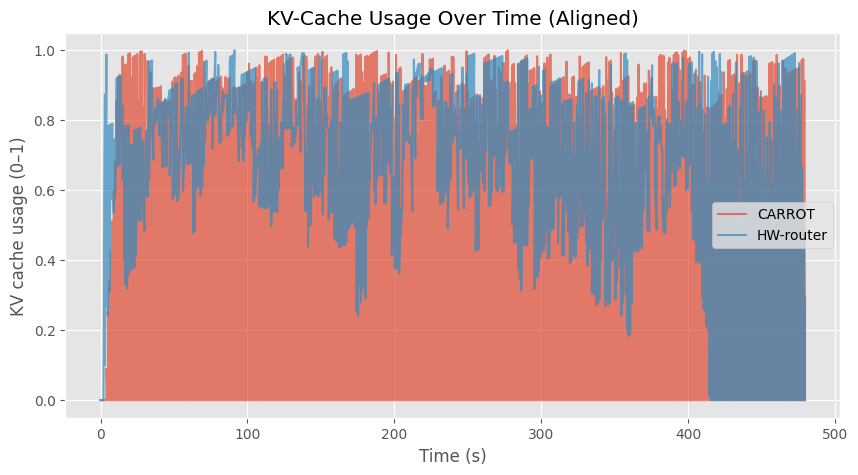

In [34]:
plt.figure(figsize=(10,5))
plt.plot(cg["t_rel"], cg["kv_cache_usage"], alpha=0.7, label="CARROT")
plt.plot(hg["t_rel"], hg["kv_cache_usage"], alpha=0.7, label="HW-router")
plt.title("KV-Cache Usage Over Time (Aligned)")
plt.xlabel("Time (s)")
plt.ylabel("KV cache usage (0–1)")
plt.legend()
plt.show()


In [35]:
def imbalance(df):
    g = df.groupby("t_rel")
    return pd.DataFrame({
        "running_std": g["running"].std(),
        "waiting_std": g["waiting"].std(),
        "kv_std":      g["kv_cache_usage"].std(),
    })
    
imb_c = imbalance(cg)
imb_h = imbalance(hg)


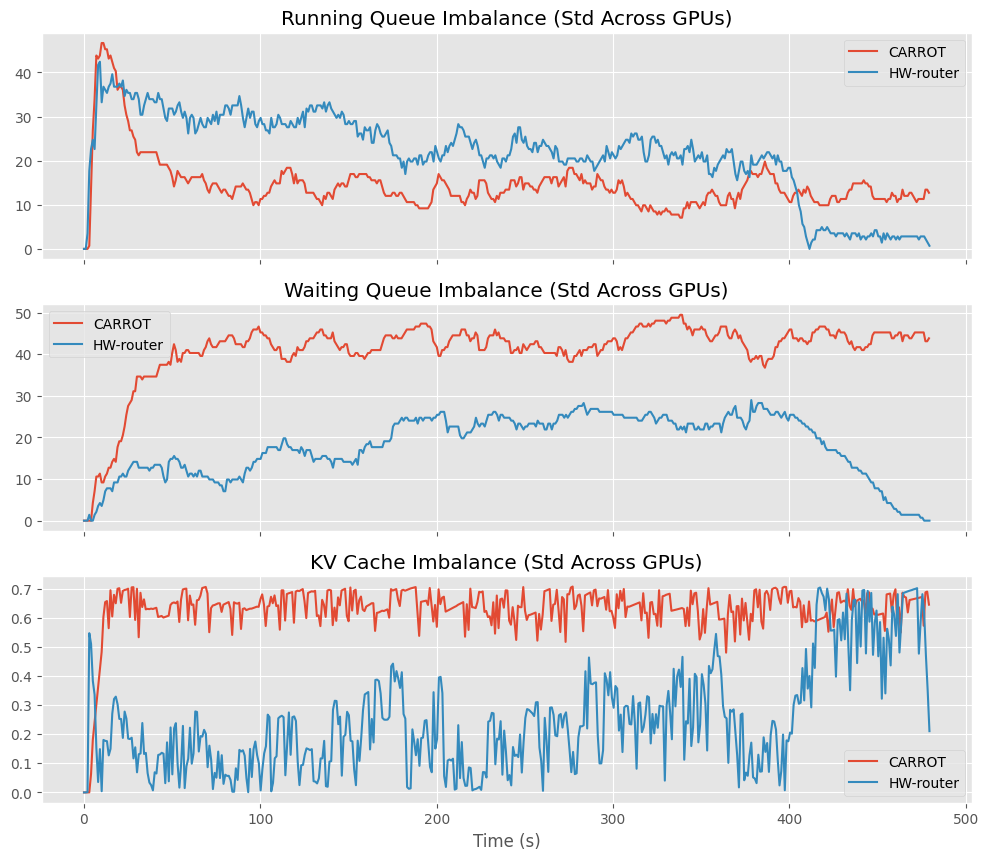

In [36]:
fig, ax = plt.subplots(3,1, figsize=(12,10), sharex=True)

ax[0].plot(imb_c.index, imb_c["running_std"], label="CARROT")
ax[0].plot(imb_h.index, imb_h["running_std"], label="HW-router")
ax[0].set_title("Running Queue Imbalance (Std Across GPUs)")
ax[0].legend()

ax[1].plot(imb_c.index, imb_c["waiting_std"], label="CARROT")
ax[1].plot(imb_h.index, imb_h["waiting_std"], label="HW-router")
ax[1].set_title("Waiting Queue Imbalance (Std Across GPUs)")
ax[1].legend()

ax[2].plot(imb_c.index, imb_c["kv_std"], label="CARROT")
ax[2].plot(imb_h.index, imb_h["kv_std"], label="HW-router")
ax[2].set_title("KV Cache Imbalance (Std Across GPUs)")
ax[2].legend()

plt.xlabel("Time (s)")
plt.show()


In [37]:
print("CARROT avg running:", df_cg["running"].mean())
print("HW avg running:", df_hg["running"].mean())


CARROT avg running: 9.191161356628983
HW avg running: 21.341666666666665


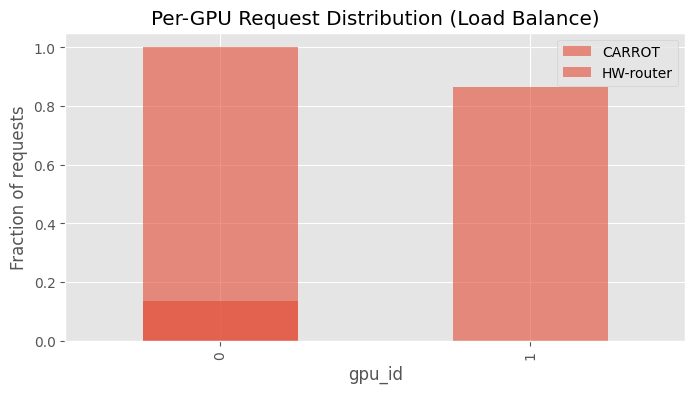

In [38]:
plt.figure(figsize=(8,4))
(df_cr["gpu_id"].value_counts(normalize=True).sort_index()).plot(kind="bar", alpha=0.6, label="CARROT")
(df_hr["gpu_id"].value_counts(normalize=True).sort_index()).plot(kind="bar", alpha=0.6, label="HW-router")
plt.legend()
plt.title("Per-GPU Request Distribution (Load Balance)")
plt.ylabel("Fraction of requests")
plt.show()


In [39]:
summary = pd.DataFrame({
    "CARROT": {
        "avg_running": cg["running"].mean(),
        "avg_waiting": cg["waiting"].mean(),
        "avg_kv":      cg["kv_cache_usage"].mean(),
        "running_imbalance": imb_c["running_std"].mean(),
        "waiting_imbalance": imb_c["waiting_std"].mean(),
        "kv_imbalance":      imb_c["kv_std"].mean(),
    },
    "HW-router": {
        "avg_running": hg["running"].mean(),
        "avg_waiting": hg["waiting"].mean(),
        "avg_kv":      hg["kv_cache_usage"].mean(),
        "running_imbalance": imb_h["running_std"].mean(),
        "waiting_imbalance": imb_h["waiting_std"].mean(),
        "kv_imbalance":      imb_h["kv_std"].mean(),
    }
}).T

summary


,avg_running,avg_waiting,avg_kv,running_imbalance,waiting_imbalance,kv_imbalance
CARROT,10.329167,29.065625,0.446203,14.607648,41.105001,0.631027
HW-router,21.341667,12.952083,0.671806,21.652199,18.084256,0.247593
